# Hybrid AQI Model with Walk-Forward Validation

This notebook replaces a single 80/20 split with walk-forward time-series validation using `TimeSeriesSplit`. The XGBoost model is tuned on mean cross-validated $R^2$ instead of one test split.

## 1. Imports and Data Loading

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

df_raw = pd.read_csv('Dataset.csv')
df_raw['Date'] = pd.to_datetime(df_raw['Date'])
df_raw = df_raw.rename(columns={'City': 'city', 'Date': 'date'})

print('Rows:', len(df_raw))
print('Columns:', list(df_raw.columns))
print('Cities:', df_raw['city'].dropna().unique()[:10])

Rows: 29531
Columns: ['city', 'date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']
Cities: <StringArray>
[   'Ahmedabad',       'Aizawl',    'Amaravati',     'Amritsar',
    'Bengaluru',       'Bhopal', 'Brajrajnagar',   'Chandigarh',
      'Chennai',   'Coimbatore']
Length: 10, dtype: str


## 2. City Selection and Preprocessing

In [11]:
aqi_counts = df_raw.groupby('city')['AQI'].apply(lambda s: s.notna().sum()).sort_values(ascending=False)
CITY = 'Ahmedabad'
if CITY not in aqi_counts.index or aqi_counts.get(CITY, 0) == 0:
    CITY = aqi_counts.index[0]

df = df_raw[df_raw['city'] == CITY].copy().sort_values('date').set_index('date')

target = 'AQI'
pollutants = [c for c in ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3'] if c in df.columns]
weather = [c for c in ['t2m', 'd2m', 'sp', 'blh', 'u10', 'v10'] if c in df.columns]
base_cols = pollutants + weather + [target]
df = df[base_cols].copy()

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

feature_fill_cols = [c for c in df.columns if c != target]
df[feature_fill_cols] = df[feature_fill_cols].ffill().bfill()
df[feature_fill_cols] = df[feature_fill_cols].fillna(0)
df = df.dropna(subset=[target]).copy()

print('City:', CITY)
print('Available AQI rows for city:', int(aqi_counts.get(CITY, 0)))
print('Rows after cleaning:', len(df))
print('Missing values:', int(df.isna().sum().sum()))
df.head()

City: Ahmedabad
Available AQI rows for city: 1334
Rows after cleaning: 1334
Missing values: 0


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI
date,,,,,,,,,,
2015-01-29,83.13,141.54,6.93,28.71,33.72,0.0,6.93,49.52,59.76,209.0
2015-01-30,79.84,141.54,13.85,28.68,41.08,0.0,13.85,48.49,97.07,328.0
2015-01-31,94.52,141.54,24.39,32.66,52.61,0.0,24.39,67.39,111.33,514.0
2015-02-01,135.99,141.54,43.48,42.08,84.57,0.0,43.48,75.23,102.70,782.0
2015-02-02,178.33,141.54,54.56,35.31,72.80,0.0,54.56,55.04,107.38,914.0


## 3. Feature Engineering

In [12]:
for lag in [1, 2, 3, 7, 14, 21, 28]:
    df[f'AQI_lag_{lag}'] = df[target].shift(lag)

for window in [7, 14, 30]:
    shifted = df[target].shift(1)
    df[f'AQI_roll_{window}_mean'] = shifted.rolling(window).mean()
    df[f'AQI_roll_{window}_std'] = shifted.rolling(window).std()
    df[f'AQI_roll_{window}_min'] = shifted.rolling(window).min()
    df[f'AQI_roll_{window}_max'] = shifted.rolling(window).max()

df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['day_of_year'] = df.index.dayofyear
df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df = df.dropna().copy()

feature_cols = [c for c in df.columns if c != target]
X = df[feature_cols].copy()
y = df[target].copy()

print('Feature count:', len(feature_cols))
print('Final rows:', len(df))
X.head()

Feature count: 36
Final rows: 1304


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI_lag_1,...,AQI_roll_30_min,AQI_roll_30_max,day_of_week,month,day_of_year,is_weekend,dow_sin,dow_cos,month_sin,month_cos
date,,,,,,,,,,,,,,,,,,,,,
2015-03-04,93.88,141.54,18.21,29.38,47.01,0.0,18.21,62.75,46.79,408.0,...,149.0,1247.0,2,3,63,0,0.974928,-0.222521,1.0,6.123234e-17
2015-03-05,173.01,141.54,48.44,42.27,90.73,0.0,48.44,78.76,59.39,383.0,...,149.0,1247.0,3,3,64,0,0.433884,-0.900969,1.0,6.123234e-17
2015-03-08,71.56,141.54,3.51,16.83,20.32,0.0,3.51,30.28,57.16,780.0,...,149.0,1247.0,6,3,67,1,-0.781831,0.623490,1.0,6.123234e-17
2015-03-09,119.80,141.54,4.13,24.07,27.90,0.0,4.13,50.35,50.49,190.0,...,149.0,1247.0,0,3,68,0,0.000000,1.000000,1.0,6.123234e-17
2015-03-10,106.71,141.54,5.39,25.59,30.51,0.0,5.39,38.85,60.17,233.0,...,149.0,1247.0,1,3,69,0,0.781831,0.623490,1.0,6.123234e-17


## 4. Holdout Split and Walk-Forward CV

In [13]:
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print('Train rows:', len(X_train))
print('Test rows :', len(X_test))

n_splits = min(5, len(X_train) - 1)
if n_splits < 2:
    raise ValueError(f'Not enough training samples for walk-forward CV: {len(X_train)} rows')
tscv = TimeSeriesSplit(n_splits=n_splits)
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):
    print(f'Fold {fold}: train={len(train_idx)}, val={len(val_idx)}')

Train rows: 1043
Test rows : 261
Fold 1: train=178, val=173
Fold 2: train=351, val=173
Fold 3: train=524, val=173
Fold 4: train=697, val=173
Fold 5: train=870, val=173


## 5. XGBoost Tuning on Mean CV $R^2$

In [14]:
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    random_state=RANDOM_SEED,
    n_jobs=-1
)

param_distributions = {
    'n_estimators': [300, 500, 800, 1200, 1600],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 3, 5, 7, 10],
    'gamma': [0, 0.1, 0.3, 0.5, 1, 2],
    'reg_alpha': [0, 0.01, 0.1, 0.5, 1, 5],
    'reg_lambda': [0.5, 1, 2, 5, 10]
}

search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=30,
    scoring='r2',
    cv=tscv,
    verbose=1,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    refit=True
)

search.fit(X_train, y_train)

print('Best CV R^2:', round(search.best_score_, 4))
print('Best params:')
print(search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV R^2: 0.5666
Best params:
{'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 8, 'learning_rate': 0.01, 'gamma': 1, 'colsample_bytree': 0.7}


## 6. Final Holdout Evaluation

In [15]:
best_model = search.best_estimator_
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'Holdout MAE : {mae:.3f}')
print(f'Holdout RMSE: {rmse:.3f}')
print(f'Holdout R^2 : {r2:.4f}')

results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
}, index=y_test.index)
results.head(10)

Holdout MAE : 62.991
Holdout RMSE: 103.458
Holdout R^2 : 0.8545


,Actual,Predicted
date,,
2019-10-07,1217.0,723.028015
2019-10-08,659.0,750.502686
2019-10-09,1389.0,907.839844
2019-10-10,1195.0,1111.417603
2019-10-11,615.0,604.558960
2019-10-12,904.0,1096.540283
2019-10-13,1595.0,1409.719238
2019-10-15,919.0,1072.115479
2019-10-16,1190.0,637.883606


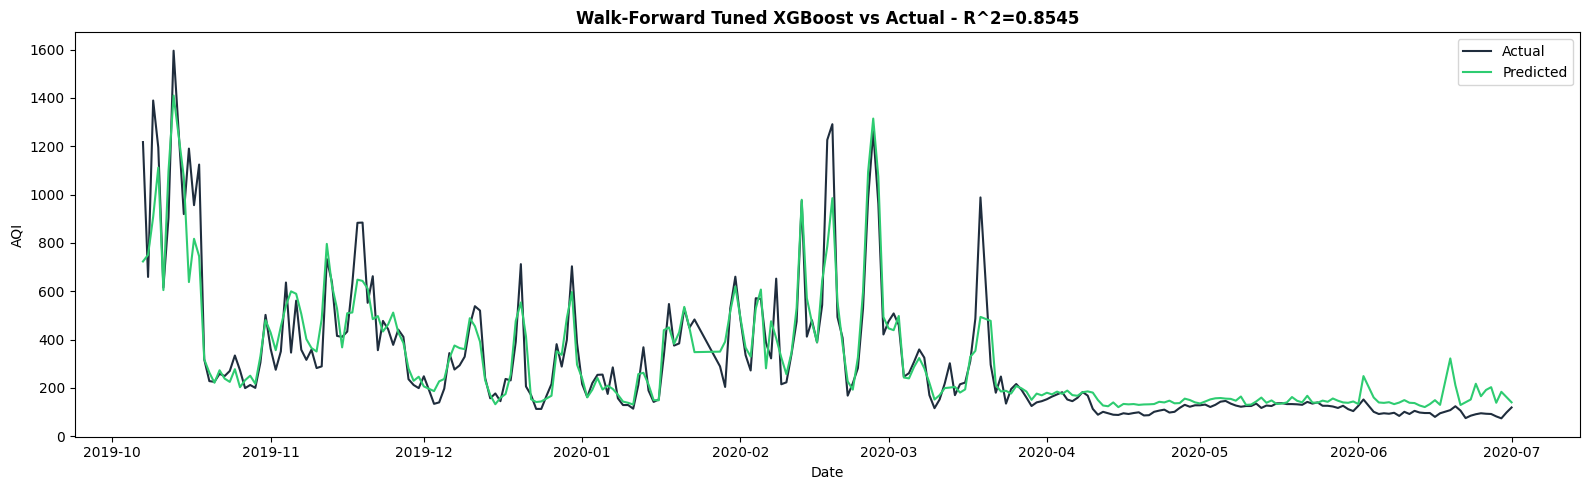

In [16]:
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(y_test.index, y_test.values, label='Actual', color='#1f2d3d', linewidth=1.5)
ax.plot(y_test.index, y_pred, label='Predicted', color='#2ecc71', linewidth=1.5)
ax.set_title(f'Walk-Forward Tuned XGBoost vs Actual - R^2={r2:.4f}', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('AQI')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Notes

- The cross-validation score is the main tuning target.
- The final holdout score is only for an unbiased check after tuning.
- If you want higher $R^2$, try adding more lag windows, pollutant interactions, or SARIMA features after this validation backbone is in place.